In [1]:
from dotenv import load_dotenv
_ = load_dotenv()

In [2]:
!pip install langchain_community
!pip install langchain_openai
!pip install langchain-groq #freemodel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.0/503.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.16
    Uninstalling langchain-core-1.2.16:
      Successfully uninstalled langchain-core-1.2.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is 

In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_community.tools.tavily_search import TavilySearchResults

In [4]:
#from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

In [5]:
import os
from google.colab import userdata

# Retrieve the API key from Colab secrets
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [6]:
tool = TavilySearchResults(max_results=2)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


/tmp/ipykernel_786/356220288.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


In [7]:
# AgentState is a dict which defines a contract.
# i.e. the key should be messages and the value corresponding to this key should be list[AnyMessage]
# we can access the key using state['messages'] where state is an instance of AgentState
class AgentState(TypedDict):
  messages: Annotated[list[AnyMessage], operator.add]

### Defining the Agent

In [8]:
class Agent:

  def __init__(self, model, tools, system=""):
    self.system = system

    #define a langgraph
    graph = StateGraph(AgentState)

    #adding nodes to the graph and define what methods these nodes should call
    graph.add_node("llm", self.call_llm)
    graph.add_node("action", self.take_action)

    #If there is some tool calling from llm, we will go to action node, else we end the loop
    graph.add_conditional_edges(
        "llm",
        self.exists_action,
        {True: "action", False: END}
    )
    graph.add_edge("action", "llm")
    graph.set_entry_point("llm")

    self.graph = graph.compile()

    #dict of tools
    self.tools = {t.name: t for t in tools}

    #binding the model with the tools
    #responses from llm (AIMessage object) will always contain the last parameter as tool_calls : [empty or non-empty]
    self.model = model.bind_tools(tools)


 #for the "llm" node we will call a method
  def call_llm(self, state: AgentState):
    messages = state["messages"]

    # We add this each time invoking the llm because we want the
    # persistent context + handle statelessness of LLM calls
    if self.system:
      messages = [SystemMessage(content=self.system)] + messages
    llmResponse = self.model.invoke(messages)

    # as method is a part of langgraph node so the result will automatically be appended to agentState
    return {"messages" : [llmResponse]}

  def take_action(self, state: AgentState):
    tool_calls = state['messages'][-1].tool_calls
    results = []

    for t in tool_calls:
      print(f"Calling: {t}")
      if not t['name'] in self.tools:      # check for bad tool name from LLM
        print("\n ....bad tool name....")
        result = "bad tool name, retry"  # instruct LLM to retry if bad
      else:
        result = self.tools[t['name']].invoke(t['args'])

    results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
    print("Back to the model!")
    return {'messages': results}

  def exists_action(self, state: AgentState):
    result = state['messages'][-1]
    return len(result.tool_calls) > 0



In [9]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

In [10]:
model = ChatGroq(temperature=0, model_name="llama-3.1-8b-instant")
zarvis = Agent(model, [tool], system=prompt)

In [11]:
!apt-get install -y graphviz graphviz-dev
!pip install pygraphviz


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 2 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main a

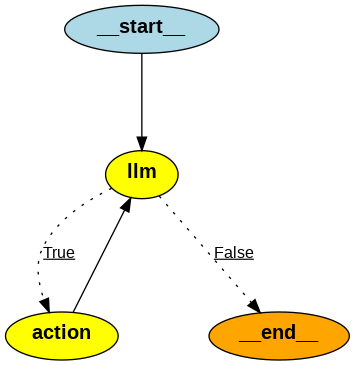

In [12]:
from IPython.display import Image

Image(zarvis.graph.get_graph().draw_png())

#### query 1

In [13]:
messages = [HumanMessage(content="What is the weather in delhi?")]
result = zarvis.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'delhi weather'}, 'id': 'fm90xbdqw', 'type': 'tool_call'}
Back to the model!


In [14]:
result

{'messages': [HumanMessage(content='What is the weather in delhi?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fm90xbdqw', 'function': {'arguments': '{"query":"delhi weather"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 351, 'total_tokens': 371, 'completion_time': 0.031815735, 'completion_tokens_details': None, 'prompt_time': 0.024918809, 'prompt_tokens_details': None, 'queue_time': 0.061599929, 'total_time': 0.056734544}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d317489708', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd6ec-78cc-7d61-884e-d074e057caef-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'delhi weather'}, 'id': 'fm90xbdqw', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inpu



```
messages:

  - type: HumanMessage
    content: "What is the weather in delhi?"

  - type: AIMessage
    content: ""
    tool_calls:
      - id: n5awbehyd
        type: function
        function:
          name: tavily_search_results_json
          arguments:
            query: "delhi weather"

    metadata:
      model: llama-3.1-8b-instant
      provider: groq
      finish_reason: tool_calls
      token_usage:
        prompt_tokens: 351
        completion_tokens: 20
        total_tokens: 371


  - type: ToolMessage
    tool_name: tavily_search_results_json
    tool_call_id: n5awbehyd
    content:
      - title: "Delhi weather in March 2026 | Delhi 14 day weather"
        url: https://www.weather25.com/asia/india/delhi?page=month&month=March
        key_info:
          avg_temperature: "20°C – 33°C"
          conditions: "Mostly clear"
          rainfall: "Very low"
          example_days:
            - Mar 10: "38° / 24° - Clear"
            - Mar 11: "39° / 24° - Clear"
            - Mar 12: "39° / 24° - Clear"
            - Mar 13: "39° / 24° - Clear"

      - title: "Historical Weather: Delhi, India (March 2026)"
        url: https://www.predictwind.com/es/weather/india/delhi/delhi/march
        key_info:
          avg_temp: "26°C"
          rainfall: "0 mm"
          avg_wind: "8 kt"
          max_gust: "26 kt"


  - type: AIMessage
    content: |
      The current weather in Delhi is hot, with average temperatures between
      **20°C and 33°C**.

      In March:
      - Weather is generally **warm and dry**
      - Only **a few rainy days**
      - Average wind speed: **~8 kt**
      - Highest gust: **~26 kt**

      Overall, March weather in Delhi is typically **clear and comfortable but warm**.

    metadata:
      model: llama-3.1-8b-instant
      provider: groq
      finish_reason: stop
      token_usage:
        prompt_tokens: 1542
        completion_tokens: 61
        total_tokens: 1603
```



In [15]:
result["messages"][-1].content

'The current weather in Delhi is hot, with average temperatures between 20°C and 33°C. There are a few rainy days expected in Delhi during March, but the weather is generally comfortable. The forecast for the next few days is clear skies with high temperatures around 39°C.'

#### query 2

In [16]:
query = "Who won the ICC men T20 in 2026."
messages = [HumanMessage(content=query)]

In [20]:
messages

[HumanMessage(content='Who won the ICC men T20 in 2026.', additional_kwargs={}, response_metadata={})]

In [17]:
result = zarvis.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'ICC men T20 2026 winner'}, 'id': 'z87jaa56m', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'ICC men T20 2026 runner up'}, 'id': '59w4q6bym', 'type': 'tool_call'}
Back to the model!


In [19]:
result

{'messages': [HumanMessage(content='Who won the ICC men T20 in 2026.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'z87jaa56m', 'function': {'arguments': '{"query":"ICC men T20 2026 winner"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 355, 'total_tokens': 380, 'completion_time': 0.032743863, 'completion_tokens_details': None, 'prompt_time': 0.064942687, 'prompt_tokens_details': None, 'queue_time': 0.062818712, 'total_time': 0.09768655}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd6ec-89e4-7ec2-9eb3-cbb48c4e9d20-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'ICC men T20 2026 winner'}, 'id': 'z87jaa56m', 'type': 'tool_call'}], invalid_tool_calls=[],



```
messages:

  - type: HumanMessage
    content: "Who won the ICC men T20 in 2026."

    metadata:
      additional_kwargs: {}
      response_metadata: {}
```



### Step 1. LLM deciedes to call the search tool

```
- type: AIMessage
    content: ""

    tool_calls:
      - id: z87jaa56m
        type: function
        function:
          name: tavily_search_results_json
          arguments:
            query: "ICC men T20 2026 winner"

    metadata:
      model: llama-3.1-8b-instant
      model_provider: groq
      finish_reason: tool_calls
      system_fingerprint: fp_020e283281

      token_usage:
        prompt_tokens: 355
        completion_tokens: 25
        total_tokens: 380

      timing:
        completion_time: 0.0327
        prompt_time: 0.0649
        queue_time: 0.0628
        total_time: 0.0976
```



### Step 2 :  Search tool return results

```
- type: ToolMessage
    tool_name: tavily_search_results_json
    tool_call_id: z87jaa56m

    results:

      - title: "2026 Men's T20 World Cup - Wikipedia"
        url: https://en.wikipedia.org/wiki/2026_Men%27s_T20_World_Cup
        score: 0.9994642

        snippet: |
          Semi-final 2 – 5 March 2026
          India 253/7 (20 overs)
          England 246/7 (20 overs)

          Result: India won by 7 runs
          Player of the match: Sanju Samson

      - title: "ICC Men's T20 World Cup 2026 - ESPNcricinfo"
        url: https://www.espncricinfo.com/series/icc-men-s-t20-world-cup-2025-26-1502138
        score: 0.9990746

        snippet: |
          ESPNcricinfo coverage of ICC Men's T20 World Cup 2026.
          India's top order performed exceptionally.
          Several Indian players featured in the tournament team.
```



### Step 3 -  LLM decides again to call search tool for runner up

```
  - type: AIMessage
    content: ""

    tool_calls:
      - id: 59w4q6bym
        type: function
        function:
          name: tavily_search_results_json
          arguments:
            query: "ICC men T20 2026 runner up"

    metadata:
      model: llama-3.1-8b-instant
      finish_reason: tool_calls

      token_usage:
        prompt_tokens: 1765
        completion_tokens: 26
        total_tokens: 1791
```



### Step 4 : Serach tool returns results with a score

```
  - type: ToolMessage
    tool_name: tavily_search_results_json
    tool_call_id: 59w4q6bym

    results:

      - title: "ICC Men's T20 World Cup 2026"
        url: https://www.t20worldcup.com/tournaments/mens-t20-world-cup-2026
        score: 0.85008353

        snippet: |
          Player highlights from ICC Men's T20 World Cup 2026.
          Includes statistics for players like Sanju Samson,
          Tim Seifert, Lungi Ngidi, and others.

      - title: "Full list of ICC T20 World Cup winners"
        url: https://www.business-standard.com/cricket/icc-t20-world-cup/2007-to-2026-full-list-of-icc-t20-world-cup-winners-and-runners-up
        score: 0.8488849

        snippet: |
          2026 Winner: India
          Captain: Suryakumar Yadav

          Runner-up: New Zealand
          Captain: Mitchell Santner

          Result:
          India won by 96 runs
          Venue: Narendra Modi Stadium, Ahmedabad
```



### Step 5 : LLM gives the final answer

```
  - type: AIMessage
    content: |
      The winner of the ICC men's T20 World Cup in 2026 was India,
      and the runner-up was New Zealand.

    metadata:
      model: llama-3.1-8b-instant
      finish_reason: stop
      system_fingerprint: fp_d317489708

      token_usage:
        prompt_tokens: 3157
        completion_tokens: 27
        total_tokens: 3184

      timing:
        completion_time: 0.0388
        prompt_time: 0.2221
        queue_time: 0.0693
        total_time: 0.2610
```



In [18]:
result["messages"][-1].content

"The winner of the ICC men's T20 World Cup in 2026 was India, and the runner-up was New Zealand."